In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f9f9f9',
    'axes.grid': True, 'grid.color': '#e0e0e0',
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11
})
PALETTE = ['#378ADD', '#534AB7', '#3B6D11', '#BA7517', '#993556']
print('Libraries loaded.')

Libraries loaded.


In [ ]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [ ]:
print('--- Data Types ---')
print(df.dtypes)
print('\n--- Null Counts ---')
print(df.isnull().sum())
print('\n--- Basic Statistics ---')
df.describe()

--- Data Types ---
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

--- Null Counts ---
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

--- Basic Statistics ---


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


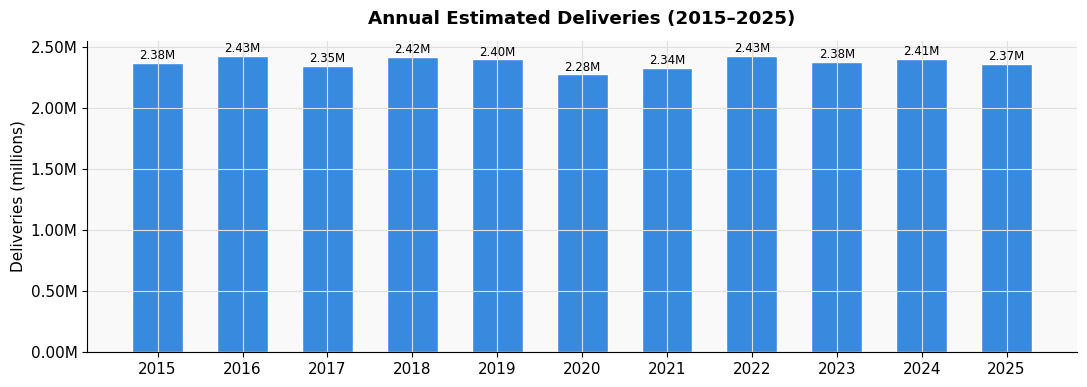

In [ ]:
# Annual delivery totals
by_year = df.groupby('Year')['Estimated_Deliveries'].sum() / 1e6

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(by_year.index, by_year.values, color=PALETTE[0], width=0.6, edgecolor='white')
ax.set_title('Annual Estimated Deliveries (2015–2025)', fontweight='bold', pad=12)
ax.set_ylabel('Deliveries (millions)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2fM'))
ax.set_xticks(by_year.index)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
            f'{b.get_height():.2f}M', ha='center', va='bottom', fontsize=8.5)
plt.tight_layout(); plt.show()

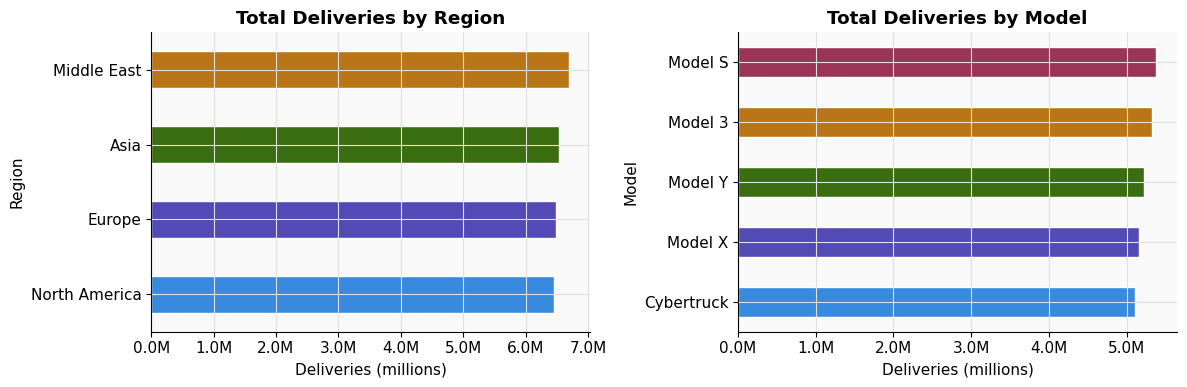

In [ ]:
# Region and Model breakdown
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes,
        ['Region', 'Model'],
        ['Total Deliveries by Region', 'Total Deliveries by Model']):
    series = df.groupby(col)['Estimated_Deliveries'].sum().sort_values() / 1e6
    series.plot(kind='barh', ax=ax, color=PALETTE, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Deliveries (millions)')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1fM'))
plt.tight_layout(); plt.show()

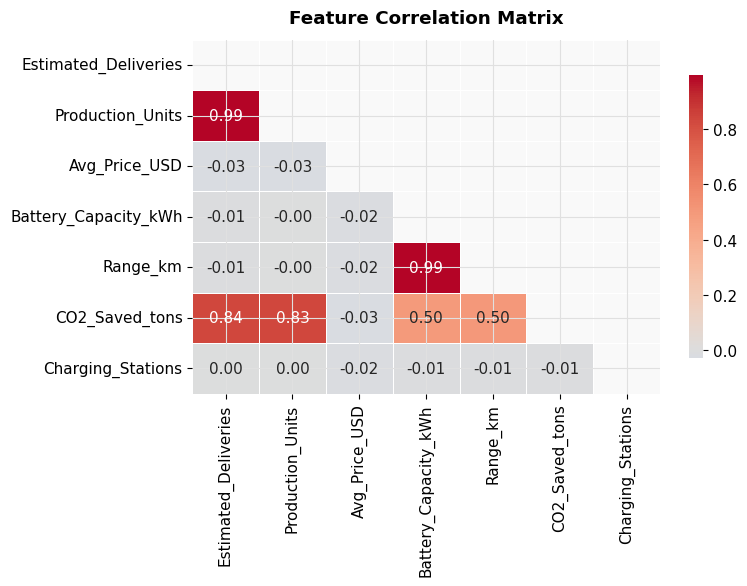

Note: Production_Units has 0.994 correlation with Estimated_Deliveries — included as a feature.


In [ ]:
# Correlation heatmap (numeric features only)
num_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
            'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontweight='bold', pad=12)
plt.tight_layout(); plt.show()
print('Note: Production_Units has 0.994 correlation with Estimated_Deliveries — included as a feature.')

In [ ]:
class DateFeatureExtractor(BaseEstimator, TransformerMixin):
    """Derives date_ordinal and quarter from Year and Month columns."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=['Year', 'Month'])
        date_ordinal = X['Year'] * 12 + X['Month']
        quarter      = ((X['Month'] - 1) // 3) + 1
        return np.column_stack([date_ordinal, quarter])

    def get_feature_names_out(self, input_features=None):
        return ['date_ordinal', 'quarter']


class ModelAgeTransformer(BaseEstimator, TransformerMixin):
    """Computes model_age = Year - first_year_seen_per_model.
    Fit learns the launch year per model; transform is leakage-free."""
    def fit(self, X, y=None):
        X = pd.DataFrame(X, columns=['Year', 'Model'])
        self.launch_year_ = X.groupby('Model')['Year'].min().to_dict()
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=['Year', 'Model'])
        age = X.apply(
            lambda r: r['Year'] - self.launch_year_.get(r['Model'], r['Year']), axis=1
        )
        return age.values.reshape(-1, 1)

    def get_feature_names_out(self, input_features=None):
        return ['model_age']


print('Custom transformers defined.')

Custom transformers defined.


In [ ]:
# ── Column groups ─────────────────────────────────────────────────────────────
NUMERIC_COLS     = ['Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
                    'Charging_Stations', 'Production_Units']   # ← added Production_Units
CATEGORICAL_COLS = ['Region', 'Model']
DATE_COLS        = ['Year', 'Month']
MODEL_AGE_COLS   = ['Year', 'Model']
TARGET           = 'Estimated_Deliveries'

ALL_FEATURES = list(dict.fromkeys(
    NUMERIC_COLS + CATEGORICAL_COLS + DATE_COLS + MODEL_AGE_COLS
))

# ── ColumnTransformer ─────────────────────────────────────────────────────────
# OneHotEncoder replaces OrdinalEncoder — correct for unordered nominal categories
preprocessor = ColumnTransformer(transformers=[
    ('num',       StandardScaler(),                                      NUMERIC_COLS),
    ('cat',       OneHotEncoder(handle_unknown='ignore',
                                sparse_output=False),                    CATEGORICAL_COLS),
    ('date',      DateFeatureExtractor(),                                DATE_COLS),
    ('model_age', ModelAgeTransformer(),                                 MODEL_AGE_COLS),
], remainder='drop')

print('ColumnTransformer built.')
print('Encoding: numeric → scaled | categorical → one-hot | date → ordinal+quarter | model_age')

ColumnTransformer built.
Encoding: numeric → scaled | categorical → one-hot | date → ordinal+quarter | model_age


In [ ]:
# ── Train / test split ────────────────────────────────────────────────────────
X = df[ALL_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

sample = preprocessor.fit_transform(X_train)
ohe_cats = preprocessor.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_COLS)
n_features = sample.shape[1]
print(f'Transformed shape: {sample.shape}  ({len(NUMERIC_COLS)} numeric + {len(ohe_cats)} OHE + 2 date + 1 model_age = {n_features} features)')

Train: (2112, 9)  |  Test: (528, 9)
Transformed shape: (2112, 17)  (5 numeric + 9 OHE + 2 date + 1 model_age = 17 features)


In [ ]:
def make_pipeline(estimator):
    """Wrap preprocessor + estimator in a single Pipeline."""
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor',    estimator)
    ])

def evaluate_pipeline(name, pipeline, X_tr, X_te, y_tr, y_te):
    pipeline.fit(X_tr, y_tr)
    preds = pipeline.predict(X_te)
    r2   = r2_score(y_te, preds)
    mae  = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    cv   = cross_val_score(pipeline, X_tr, y_tr, cv=5, scoring='r2').mean()
    print(f'{name:<26}  R²={r2:+.4f}  MAE={mae:,.0f}  RMSE={rmse:,.0f}  CV-R²={cv:+.4f}')
    return {'pipeline': pipeline, 'preds': preds, 'r2': r2, 'mae': mae, 'rmse': rmse, 'cv_r2': cv}

pipelines = {
    'Linear Regression': make_pipeline(LinearRegression()),
    'Ridge (α=10)':      make_pipeline(Ridge(alpha=10)),
    'Random Forest':     make_pipeline(RandomForestRegressor(n_estimators=100, random_state=42)),
    'Gradient Boosting': make_pipeline(GradientBoostingRegressor(n_estimators=150, random_state=42)),
}

results = {}
print(f'{"Model":<26}  {"R²":>8}  {"MAE":>8}  {"RMSE":>8}  {"CV R²":>8}')
print('-' * 68)
for name, pipe in pipelines.items():
    results[name] = evaluate_pipeline(name, pipe, X_train, X_test, y_train, y_test)

Model                             R²       MAE      RMSE     CV R²
--------------------------------------------------------------------
Linear Regression           R²=+0.9883  MAE=340  RMSE=418  CV-R²=+0.9883
Ridge (α=10)                R²=+0.9882  MAE=342  RMSE=419  CV-R²=+0.9883
Random Forest               R²=+0.9855  MAE=372  RMSE=464  CV-R²=+0.9865
Gradient Boosting           R²=+0.9867  MAE=358  RMSE=445  CV-R²=+0.9871


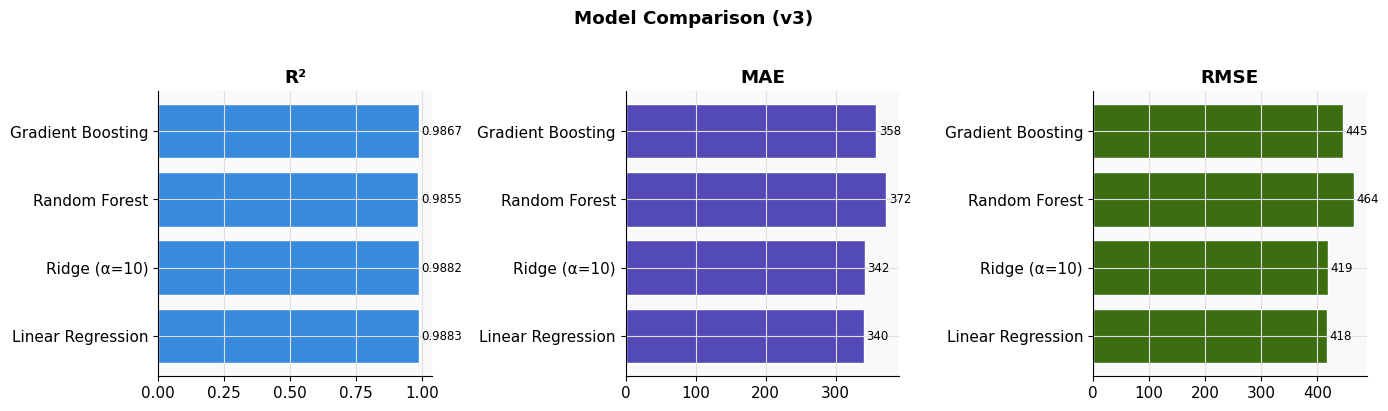

In [ ]:
# Model comparison chart
metrics_df = pd.DataFrame({
    'Model': list(results.keys()),
    'R²':    [v['r2']   for v in results.values()],
    'MAE':   [v['mae']  for v in results.values()],
    'RMSE':  [v['rmse'] for v in results.values()]
})

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(axes, ['R²', 'MAE', 'RMSE'], PALETTE[:3]):
    bars = ax.barh(metrics_df['Model'], metrics_df[col], color=color, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    for b in bars:
        w = b.get_width()
        label = f'{w:.4f}' if col == 'R²' else f'{w:,.0f}'
        ax.text(w + abs(w)*0.01, b.get_y()+b.get_height()/2,
                label, va='center', fontsize=8.5)
plt.suptitle('Model Comparison (v3)', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
rf_pipeline = make_pipeline(RandomForestRegressor(random_state=42))

param_grid = {
    'regressor__n_estimators':      [100, 200],
    'regressor__max_depth':         [5, 10, None],
    'regressor__min_samples_split': [2, 5]
}

gs = GridSearchCV(
    rf_pipeline, param_grid,
    cv=3, scoring='r2', n_jobs=-1, verbose=1
)
gs.fit(X_train, y_train)

print(f'\nBest params : {gs.best_params_}')
print(f'Best CV R²  : {gs.best_score_:.4f}')

best_preds = gs.best_estimator_.predict(X_test)
print(f'\n--- Tuned RF Pipeline on Test Set ---')
print(f'R²   = {r2_score(y_test, best_preds):+.4f}')
print(f'MAE  = {mean_absolute_error(y_test, best_preds):,.0f}')
print(f'RMSE = {np.sqrt(mean_squared_error(y_test, best_preds)):,.0f}')

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best params : {'regressor__max_depth': 5, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
Best CV R²  : 0.9870

--- Tuned RF Pipeline on Test Set ---
R²   = +0.9868
MAE  = 358
RMSE = 444


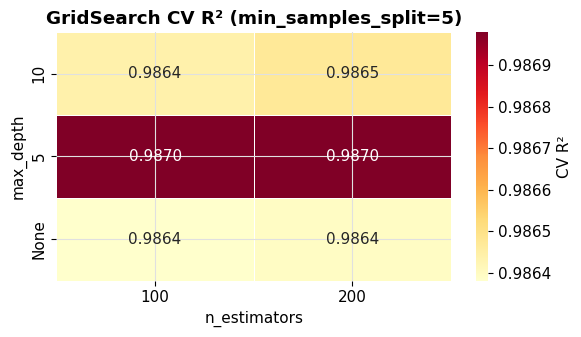

In [ ]:
# GridSearch heatmap
cv_results = pd.DataFrame(gs.cv_results_)
best_mss   = gs.best_params_['regressor__min_samples_split']
sub = cv_results[
    cv_results['param_regressor__min_samples_split'] == best_mss
].copy()
sub['depth_label'] = sub['param_regressor__max_depth'].apply(
    lambda x: str(x) if x else 'None'
)
pivot = sub.pivot_table(
    index='depth_label',
    columns='param_regressor__n_estimators',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, cbar_kws={'label': 'CV R²'})
ax.set_title(f'GridSearch CV R² (min_samples_split={best_mss})', fontweight='bold')
ax.set_xlabel('n_estimators'); ax.set_ylabel('max_depth')
plt.tight_layout(); plt.show()

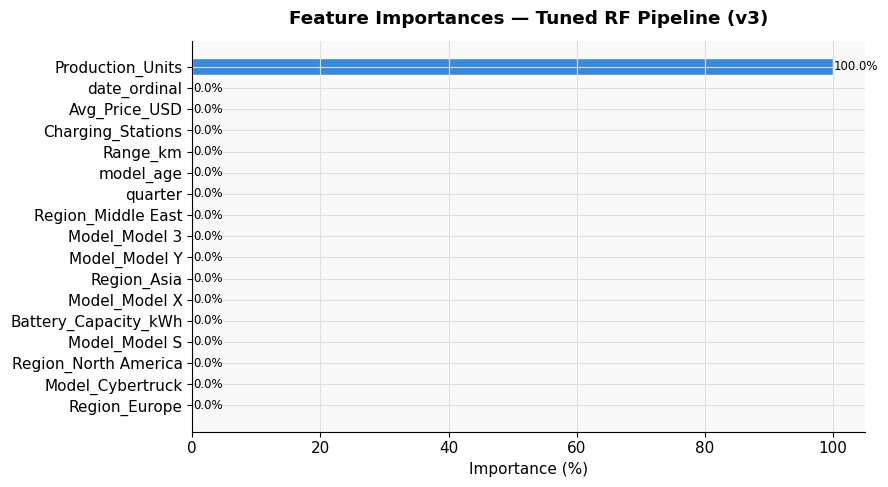

In [ ]:
# Feature importances from the tuned pipeline
best_rf    = gs.best_estimator_.named_steps['regressor']
ohe_names  = gs.best_estimator_.named_steps['preprocessor'] \
               .named_transformers_['cat'].get_feature_names_out(CATEGORICAL_COLS).tolist()
feat_names = NUMERIC_COLS + ohe_names + ['date_ordinal', 'quarter', 'model_age']
fi = pd.Series(best_rf.feature_importances_, index=feat_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [PALETTE[0] if v > fi.median() else '#B5D4F4' for v in fi.values]
bars = ax.barh(fi.index, fi.values * 100, color=colors, edgecolor='white')
for b in bars:
    ax.text(b.get_width() + 0.1, b.get_y()+b.get_height()/2,
            f'{b.get_width():.1f}%', va='center', fontsize=8.5)
ax.set_title('Feature Importances — Tuned RF Pipeline (v3)', fontweight='bold', pad=12)
ax.set_xlabel('Importance (%)')
plt.tight_layout(); plt.show()

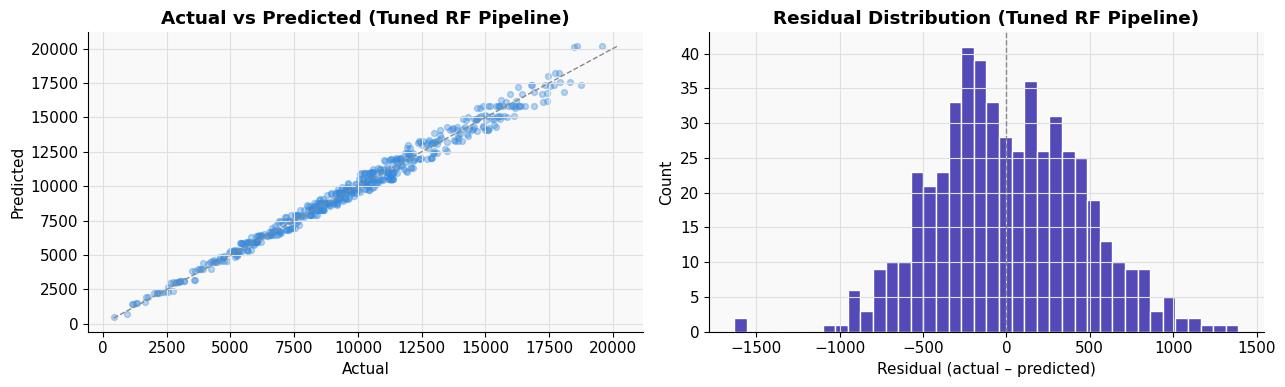

In [ ]:
# Actual vs predicted + residuals
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_test, best_preds, alpha=0.35, s=18, color=PALETTE[0])
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[0].plot(lims, lims, '--', color='#888', linewidth=1)
axes[0].set_title('Actual vs Predicted (Tuned RF Pipeline)', fontweight='bold')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')

residuals = y_test - best_preds
axes[1].hist(residuals, bins=40, color=PALETTE[1], edgecolor='white')
axes[1].axvline(0, color='#888', linestyle='--', linewidth=1)
axes[1].set_title('Residual Distribution (Tuned RF Pipeline)', fontweight='bold')
axes[1].set_xlabel('Residual (actual – predicted)')
axes[1].set_ylabel('Count')
plt.tight_layout(); plt.show()

In [ ]:
from sklearn import set_config
set_config(display='diagram')
gs.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Avg_Price_USD',
                                                   'Battery_Capacity_kWh',
                                                   'Range_km',
                                                   'Charging_Stations',
                                                   'Production_Units']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Region', 'Model']),
                                                 ('date',
                                                  DateFeatureExtractor(),
                                                  ['Year', 'Month']),
                                                 ('model_age',
                                                  ModelAgeTransformer(),
                                                  ['Year', 'Model'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=5, min_samples_split=5,
                                       n_estimators=200, random_state=42))])

In [ ]:
# Monthly global totals
ts = (
    df.groupby(['Year', 'Month'])['Estimated_Deliveries']
    .sum().reset_index().sort_values(['Year', 'Month'])
)
ts['date'] = pd.to_datetime(ts[['Year','Month']].assign(day=1))
ts = ts.set_index('date')['Estimated_Deliveries']
ts.index.freq = 'MS'   # monthly start frequency required by statsmodels

print(f'Time series length: {len(ts)} months ({ts.index[0].date()} → {ts.index[-1].date()})')
print(f'Monthly deliveries — mean: {ts.mean():,.0f}  std: {ts.std():,.0f}')

Time series length: 132 months (2015-01-01 → 2025-12-01)
Monthly deliveries — mean: 198,444  std: 16,871


In [ ]:
# Fit SARIMA(1,1,1)(1,1,1,12)
sarima = ARIMA(ts, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_result = sarima.fit()

print(sarima_result.summary().tables[0])
print(f'\nAIC: {sarima_result.aic:.2f}  |  BIC: {sarima_result.bic:.2f}')

                                    SARIMAX Results                                     
Dep. Variable:             Estimated_Deliveries   No. Observations:                  132
Model:             ARIMA(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1367.670
Date:                          Mon, 08 Jun 2026   AIC                           2745.339
Time:                                  01:35:18   BIC                           2759.235
Sample:                              01-01-2015   HQIC                          2750.982
                                   - 12-01-2025                                         
Covariance Type:                            opg                                         

AIC: 2745.34  |  BIC: 2759.24


In [ ]:
# 6-month forecast with 95% confidence interval
n_ahead  = 6
forecast = sarima_result.get_forecast(steps=n_ahead)
fc_mean  = forecast.predicted_mean
fc_ci    = forecast.conf_int(alpha=0.05)

forecast_df = pd.DataFrame({
    'Date':       fc_mean.index.strftime('%Y-%m'),
    'Forecast':   fc_mean.round(0).astype(int),
    'Lower 95%':  fc_ci.iloc[:, 0].round(0).astype(int),
    'Upper 95%':  fc_ci.iloc[:, 1].round(0).astype(int),
})
print('6-month SARIMA forecast:')
print(forecast_df.to_string(index=False))

6-month SARIMA forecast:
   Date  Forecast  Lower 95%  Upper 95%
2026-01    209863     159161     260566
2026-02    204851     146493     263209
2026-03    214176     149074     279278
2026-04    210742     139531     281952
2026-05    203975     127140     280809
2026-06    202764     120689     284839


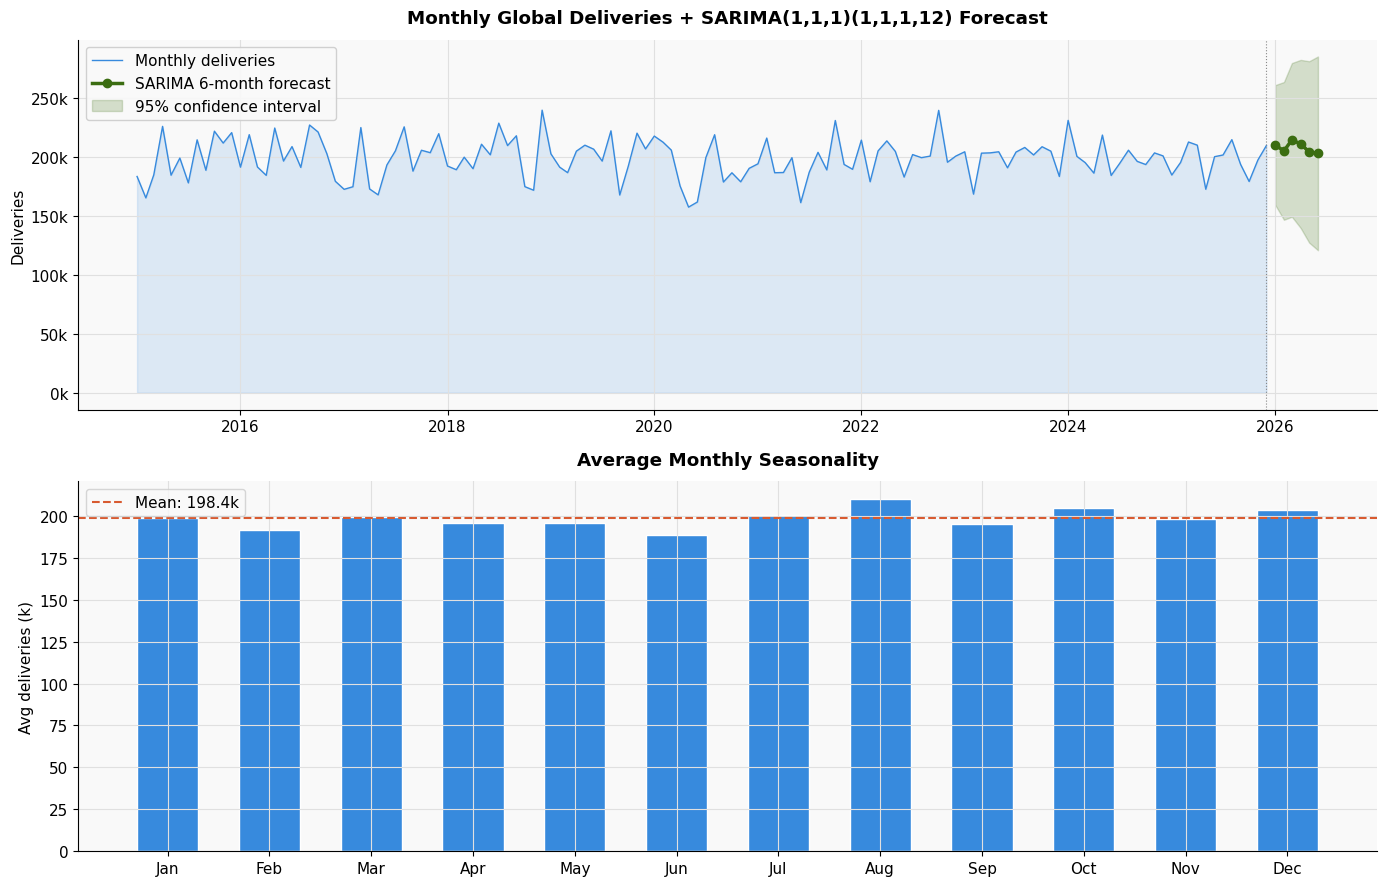

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# ── Top: time series + SARIMA forecast ──────────────────────────────────────
ax = axes[0]
ax.fill_between(ts.index, ts.values, alpha=0.15, color=PALETTE[0])
ax.plot(ts.index, ts.values, color=PALETTE[0], linewidth=1, label='Monthly deliveries')
ax.plot(fc_mean.index, fc_mean.values, color='#3B6D11', linewidth=2.5,
        marker='o', markersize=6, label='SARIMA 6-month forecast')
ax.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                alpha=0.2, color='#3B6D11', label='95% confidence interval')
ax.axvline(ts.index[-1], color='#888', linewidth=0.8, linestyle=':')
ax.set_title('Monthly Global Deliveries + SARIMA(1,1,1)(1,1,1,12) Forecast', fontweight='bold', pad=12)
ax.set_ylabel('Deliveries')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend(framealpha=0.9)

# ── Bottom: seasonality ──────────────────────────────────────────────────────
ax2 = axes[1]
seasonal = ts.groupby(ts.index.month).mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax2.bar(month_names, seasonal.values / 1000, color=PALETTE[0], edgecolor='white', width=0.6)
ax2.axhline(seasonal.mean() / 1000, color='#D85A30', linewidth=1.5,
            linestyle='--', label=f'Mean: {seasonal.mean()/1000:.1f}k')
ax2.set_title('Average Monthly Seasonality', fontweight='bold', pad=12)
ax2.set_ylabel('Avg deliveries (k)')
ax2.legend()

plt.tight_layout(); plt.show()